In [1]:
# %% [markdown]
# # Multi-Factor Equity Risk Model
# 
# This notebook builds a factor risk model similar to those used by hedge funds.
# We use free data from Yahoo Finance and Kenneth French's library.

# %% [markdown]
# ## 1. Install and Import Libraries

# %%
# If you haven't installed these libraries, run:
# !pip install yfinance pandas-datareader pandas numpy statsmodels matplotlib seaborn

In [5]:
!pip install yfinance pandas-datareader pandas numpy statsmodels matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import statsmodels.api as sm
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Set plot style
sns.set_style('whitegrid')
%matplotlib inline

In [20]:
# %% [markdown]
# ## 2. Download Stock Data
# 
# We'll pick 50 liquid stocks from the S&P 500. For simplicity, we use a predefined list.

# %%
# List of tickers (first 50 from S&P 500 by market cap – illustrative)
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'META', 'BRK-B', 'JNJ', 'V', 'PG',
           'JPM', 'UNH', 'HD', 'DIS', 'MA', 'BAC', 'NFLX', 'ADBE', 'CRM', 'PFE',
           'CSCO', 'XOM', 'ABT', 'CMCSA', 'COST', 'CVX', 'PEP', 'TMO', 'NKE', 'ABBV',
           'WMT', 'ACN', 'MCD', 'AVGO', 'TXN', 'QCOM', 'NEE', 'WFC', 'INTU', 'UPS',
           'AMGN', 'SBUX', 'MS', 'BLK', 'T', 'BMY', 'LOW', 'CAT', 'BA', 'DE']

In [21]:
# Download daily adjusted close prices from 2018-01-01 to 2023-12-31
start = '2018-01-01'
end = '2023-12-31'
prices = yf.download(tickers, start=start, end=end, auto_adjust=True, threads=False)['Close']

[*********************100%***********************]  50 of 50 completed


In [22]:
# Drop any tickers with too many missing values
prices = prices.dropna(axis=1, thresh=int(0.8 * len(prices)))
print(f"Using {prices.shape[1]} stocks")

Using 50 stocks


In [23]:
# %% [markdown]
# ## 3. Download Factor Data from Kenneth French
# 
# We'll get daily factors: Market (Mkt-RF), SMB, HML, and Momentum (Mom).
# French's data library also provides the risk‑free rate.

# %%
# Fetch daily Fama-French 3 factors (Market, SMB, HML) plus RF
ff3 = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=start, end=end)[0]

In [24]:
# Fetch daily Momentum factor (Mom)
mom = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=start, end=end)[0]

In [25]:
# Combine factors: we need Mkt-RF, SMB, HML, Mom
# Note: French's Momentum factor is already a long-short return, so we can use it directly.
factors = ff3.join(mom[['Mom']])  # column name has spaces
factors.columns = ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']
factors = factors[['Mkt-RF', 'SMB', 'HML', 'Mom', 'RF']]  # reorder
factors.index = pd.to_datetime(factors.index)

In [26]:
# Keep only dates that are in our price data
common_dates = prices.index.intersection(factors.index)
prices = prices.loc[common_dates]
factors = factors.loc[common_dates]

In [27]:
print(f"Data from {common_dates[0].date()} to {common_dates[-1].date()}")

Data from 2018-01-02 to 2023-12-29


In [28]:
# %% [markdown]
# ## 4. Calculate Stock Excess Returns

# %%
# Daily stock returns
returns = prices.pct_change().dropna()

# Risk‑free rate (daily, as a decimal)
rf = factors['RF'] / 100  # French's data is in percent

# Excess returns
excess_returns = returns.sub(rf, axis=0)

# Factor returns (also in decimal)
factor_returns = factors[['Mkt-RF', 'SMB', 'HML', 'Mom']] / 100


In [29]:
# Align again (just in case)
excess_returns = excess_returns.align(factor_returns, join='inner', axis=0)[0]
factor_returns = factor_returns.align(excess_returns, join='inner', axis=0)[0]

print(f"Excess returns shape: {excess_returns.shape}")
print(f"Factor returns shape: {factor_returns.shape}")


Excess returns shape: (1509, 50)
Factor returns shape: (1509, 4)


In [30]:
# %% [markdown]
# ## 5. Estimate Rolling Factor Exposures (Betas)
# 
# For each stock, we run a rolling regression of its excess returns on the four factors.
# We'll use a 504‑day window (two trading year).

# %%
window = 504  # rolling window length

# Prepare a DataFrame to store betas for each stock over time
# We'll store them as a MultiIndex (date, stock) or as a panel.
# Simpler: create a dictionary of DataFrames, one per factor.
betas = {factor: pd.DataFrame(index=excess_returns.index, columns=excess_returns.columns) 
         for factor in factor_returns.columns}

In [31]:
# Also store residual variances (for specific risk)
resid_vars = pd.DataFrame(index=excess_returns.index, columns=excess_returns.columns)

# Loop over each stock
for stock in excess_returns.columns:
    y = excess_returns[stock]
    X = factor_returns.copy()
    X = sm.add_constant(X)  # add intercept (alpha)
    
    # Rolling regression
    for end_date in range(window, len(X)):
        start_date = end_date - window
        y_window = y.iloc[start_date:end_date]
        X_window = X.iloc[start_date:end_date]
        
        # Fit OLS
        model = sm.OLS(y_window, X_window).fit()
        
        # Store betas (excluding const)
        date = X.index[end_date - 1]  # use the last date of the window as the estimate date
        for factor in factor_returns.columns:
            betas[factor].loc[date, stock] = model.params[factor]
        
        # Store residual variance
        resid_vars.loc[date, stock] = model.mse_resid

# Drop rows with NaN (first window-1 days)
for factor in betas:
    betas[factor] = betas[factor].dropna()
resid_vars = resid_vars.dropna()

print(f"Beta estimates from {betas['Mkt-RF'].index[0].date()} to {betas['Mkt-RF'].index[-1].date()}")


Beta estimates from 2020-01-03 to 2023-12-28


In [45]:
# %% [markdown]
# 6. Compute Rolling Factor Volatilities (and covariances) using pandas rolling
rolling_window = 504  # number of trading days in the window

# Prepare an empty DataFrame for factor volatilities (annualized)
factor_vol = pd.DataFrame(index=factor_returns.index[rolling_window-1:], 
                          columns=factor_returns.columns)

# Dictionary to store full covariance matrices (optional)
cov_matrices = {}

# Loop over each possible end index
for i in range(rolling_window, len(factor_returns) + 1):
    date = factor_returns.index[i-1]   # the end date of the window
    window_data = factor_returns.iloc[i-rolling_window:i]   # exactly `rolling_window` rows
    cov = window_data.cov()
    cov_matrices[date] = cov
    # Store annualized volatility (sqrt(diag) * sqrt(252))
    factor_vol.loc[date] = np.sqrt(np.diag(cov)) * np.sqrt(252)

# Drop any rows that might still be NaN (shouldn't happen, but just in case)
factor_vol = factor_vol.dropna()

print("factor_vol shape:", factor_vol.shape)
print("factor_vol head:\n", factor_vol.head())

# %% [markdown]
# ## 7. Build a Sample Portfolio (Equal‑Weighted)
# 
# We assume we hold an equal‑weighted portfolio of all stocks, rebalanced daily (for simplicity).

# %%
# Portfolio weights (equal at each date)
weights = pd.DataFrame(1.0 / excess_returns.shape[1], 
                       index=excess_returns.index, 
                       columns=excess_returns.columns)

# Portfolio betas = weighted average of stock betas (using the latest available betas)
# We'll align dates: betas are available at the end of each rolling window.
portfolio_betas = pd.DataFrame(index=betas['Mkt-RF'].index, columns=factor_returns.columns)

for date in portfolio_betas.index:
    # Get weights for this date (weights are constant, but we need to ensure same stocks)
    w = weights.loc[date, excess_returns.columns]  # all stocks
    for factor in factor_returns.columns:
        # Stock betas for this factor at this date
        b = betas[factor].loc[date]
        # Align weights and betas (drop any stocks missing beta)
        common = w.index.intersection(b.dropna().index)
        if len(common) > 0:
            portfolio_betas.loc[date, factor] = (w[common] * b[common]).sum() / w[common].sum()
        else:
            portfolio_betas.loc[date, factor] = np.nan

portfolio_betas = portfolio_betas.dropna()

# Portfolio specific risk: weighted sum of residual variances
# Residual variances are available at the same dates as betas
portfolio_specific_var = pd.Series(index=resid_vars.index, dtype=float)
for date in portfolio_specific_var.index:
    w = weights.loc[date, excess_returns.columns]
    rv = resid_vars.loc[date]
    common = w.index.intersection(rv.dropna().index)
    if len(common) > 0:
        portfolio_specific_var.loc[date] = (w[common]**2 * rv[common]).sum()
    else:
        portfolio_specific_var.loc[date] = np.nan

portfolio_specific_var = portfolio_specific_var.dropna()

# Align dates of portfolio betas and specific var
common_dates = portfolio_betas.index.intersection(portfolio_specific_var.index)
portfolio_betas = portfolio_betas.loc[common_dates]
portfolio_specific_var = portfolio_specific_var.loc[common_dates]



factor_vol shape: (1006, 4)
factor_vol head:
               Mkt-RF       SMB       HML       Mom
Date                                              
2020-01-02  0.153254  0.080408  0.092712  0.116323
2020-01-03  0.153229  0.080415  0.092704  0.116229
2020-01-06  0.153196  0.080372  0.092769  0.116324
2020-01-07   0.15318  0.080354  0.092761  0.116313
2020-01-08  0.153147   0.08032  0.092846  0.116421


In [33]:
# %% [markdown]
# ## 8. Decompose Portfolio Risk
# 
# For each date, we compute:
# - Systematic risk: β_p' * Ω * β_p
# - Specific risk: weighted sum of residual variances
# - Total risk: sqrt(systematic + specific)

# %%
# Initialize arrays
systematic_var = pd.Series(index=common_dates, dtype=float)
total_vol = pd.Series(index=common_dates, dtype=float)

for date in common_dates:
    beta_vec = portfolio_betas.loc[date].values  # shape (4,)
    cov_mat = cov_matrices[date]  # 4x4 DataFrame
    # Systematic variance
    systematic_var.loc[date] = beta_vec @ cov_mat.values @ beta_vec.T
    # Total variance
    total_var = systematic_var.loc[date] + portfolio_specific_var.loc[date]
    total_vol.loc[date] = np.sqrt(total_var) * np.sqrt(252)  # annualize

# Systematic risk as a fraction of total risk
systematic_frac = systematic_var / (systematic_var + portfolio_specific_var)

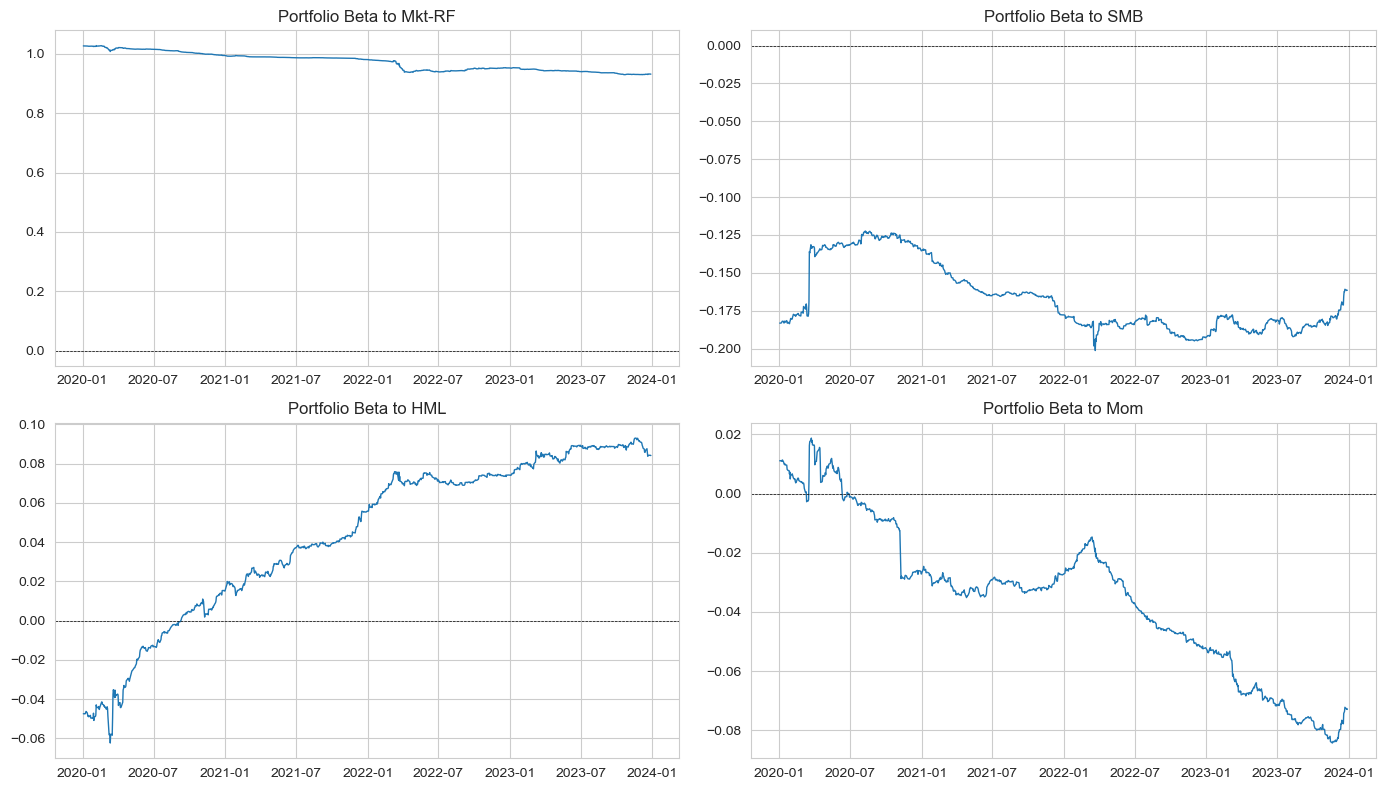

In [34]:
# %% [markdown]
# ## 9. Visualize the Results

# %%
# Plot 1: Portfolio betas over time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, factor in enumerate(factor_returns.columns):
    axes[i].plot(portfolio_betas.index, portfolio_betas[factor], linewidth=1)
    axes[i].set_title(f'Portfolio Beta to {factor}')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


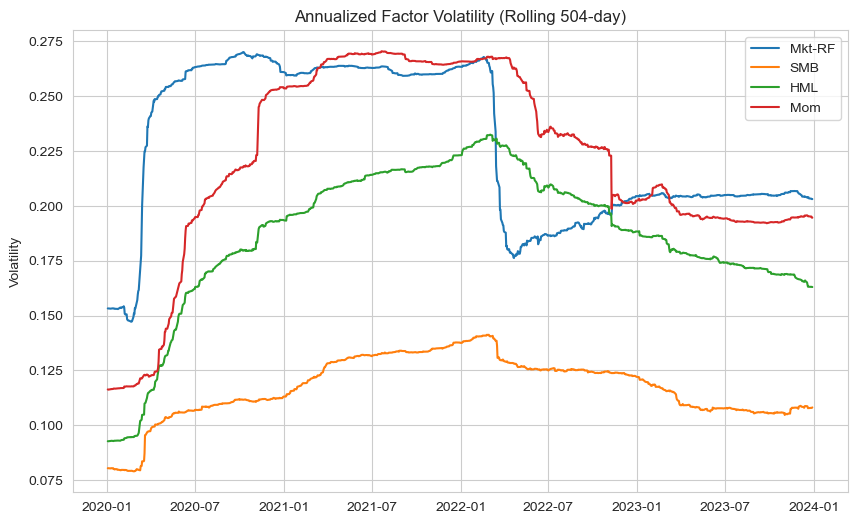

In [47]:
# %%
# Plot 2: Factor volatility (from covariance diagonal)
fig, ax = plt.subplots(figsize=(10, 6))
for factor in factor_returns.columns:
    ax.plot(factor_vol.index, factor_vol[factor], label=factor)
ax.set_title('Annualized Factor Volatility (Rolling 504-day)')
ax.set_ylabel('Volatility')
ax.legend()
plt.show()


In [46]:
print("factor_vol shape:", factor_vol.shape)
print("First few rows:\n", factor_vol.head())
print("Any NaN values left?\n", factor_vol.isnull().sum().sum())

factor_vol shape: (1006, 4)
First few rows:
               Mkt-RF       SMB       HML       Mom
Date                                              
2020-01-02  0.153254  0.080408  0.092712  0.116323
2020-01-03  0.153229  0.080415  0.092704  0.116229
2020-01-06  0.153196  0.080372  0.092769  0.116324
2020-01-07   0.15318  0.080354  0.092761  0.116313
2020-01-08  0.153147   0.08032  0.092846  0.116421
Any NaN values left?
 0


In [44]:
print("Total number of trading days in factor_returns:", len(factor_returns))

Total number of trading days in factor_returns: 1509


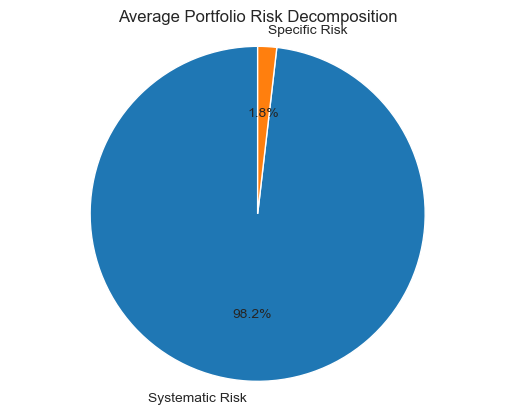

In [36]:
# %%
# Plot 3: Risk decomposition pie chart (average over period)
avg_systematic = systematic_var.mean()
avg_specific = portfolio_specific_var.mean()
labels = ['Systematic Risk', 'Specific Risk']
sizes = [avg_systematic, avg_specific]
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.axis('equal')
ax.set_title('Average Portfolio Risk Decomposition')
plt.show()

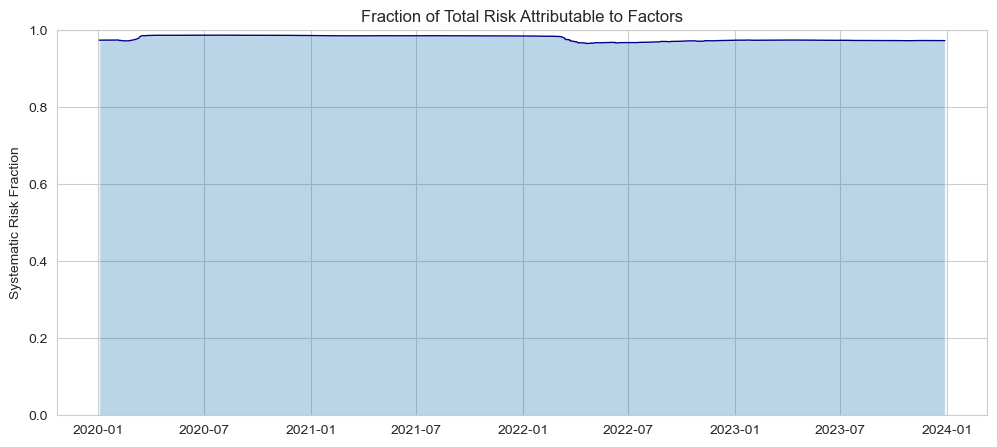

In [37]:
# %%
# Plot 4: Evolution of systematic risk fraction
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(systematic_frac.index, systematic_frac, linewidth=1, color='darkblue')
ax.fill_between(systematic_frac.index, 0, systematic_frac, alpha=0.3)
ax.set_title('Fraction of Total Risk Attributable to Factors')
ax.set_ylabel('Systematic Risk Fraction')
ax.set_ylim(0, 1)
plt.show()

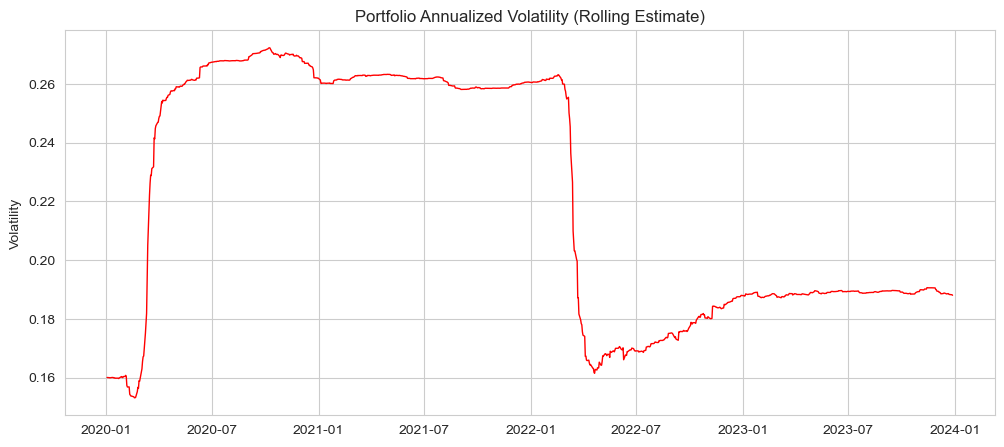

In [38]:
# %%
# Plot 5: Total portfolio annualized volatility over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(total_vol.index, total_vol, linewidth=1, color='red')
ax.set_title('Portfolio Annualized Volatility (Rolling Estimate)')
ax.set_ylabel('Volatility')
plt.show()

In [39]:
# %% [markdown]
# ## 10. Interpretation
# 
# - The portfolio betas show how sensitive our equal‑weight portfolio is to each factor.
# - Factor volatilities indicate which factors have been most turbulent.
# - The risk decomposition reveals that most of the portfolio's risk is systematic (factors), but a non‑negligible part is stock‑specific.
# - The systematic risk fraction can vary over time, increasing when factors move together.

# %% [markdown]
# ## Next Steps & Extensions
# 
# 1. **Use your own portfolio** – replace the equal weights with actual holdings.
# 2. **Construct factors yourself** – build SMB, HML, and momentum from stock data (requires fundamentals).
# 3. **Add more factors** – quality, low volatility, etc.
# 4. **Implement Bayesian shrinkage** for covariance estimation.
# 5. **Build an interactive dashboard** with Plotly Dash to monitor risk in real time.